In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/DWDM_Project/data/processed/samsung_processed_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Product,Category,Rating,Review,Platform,Date,Issue,RSI,Sentiment_score
0,Samsung Buds Live,Accessories,5,worth it house save decide although bag fight ...,Flipkart,2024-12-14,none,0.0600,0.5859
1,Samsung Galaxy M14,Smartphone,2,waste of money issue display flickering,Flipkart,2022-07-04,display,0.6536,-0.4215
2,Samsung Galaxy M53,Smartphone,5,excellent game threat see head cover task see,Flipkart,2022-07-21,none,0.0600,0.0772
3,Samsung Galaxy Tab A8,Smartphone,4,good,Amazon,2024-03-13,none,0.1350,0.4404
4,Samsung Charger 25W,Accessories,1,average join hotel daughter water,Flipkart,2024-11-13,heating,0.5600,0.2960


In [ ]:
df["Month"] = df["Date"].dt.to_period("M")

CORE ANALYSIS

1. Monthly RSI Trend

<Axes: title={'center': 'Monthly Regret Trend'}, xlabel='Month'>

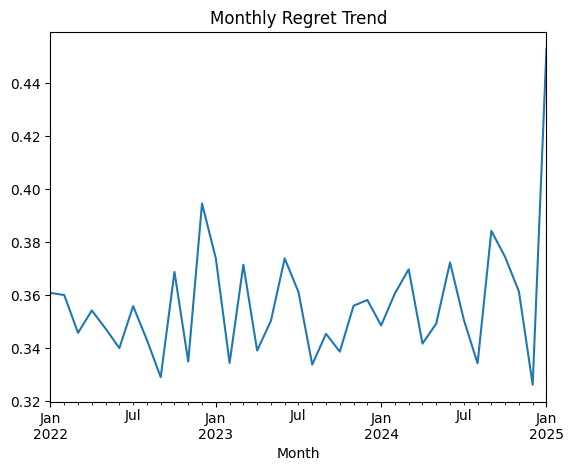

In [ ]:
monthly_trend = df.groupby("Month")["RSI"].mean()

monthly_trend.plot(title="Monthly Regret Trend")


<Axes: title={'center': 'Monthly RSI Variability'}, xlabel='Month'>

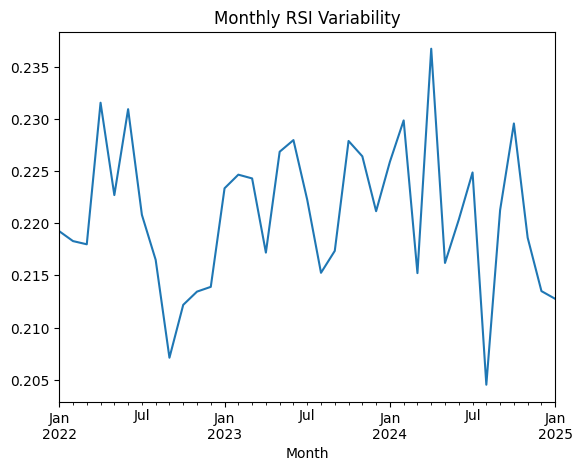

In [ ]:
monthly_std = df.groupby("Month")["RSI"].std()

monthly_std.plot(title="Monthly RSI Variability")

2. Monthly High Risk %

<Axes: title={'center': 'Monthly High Risk %'}, xlabel='Month'>

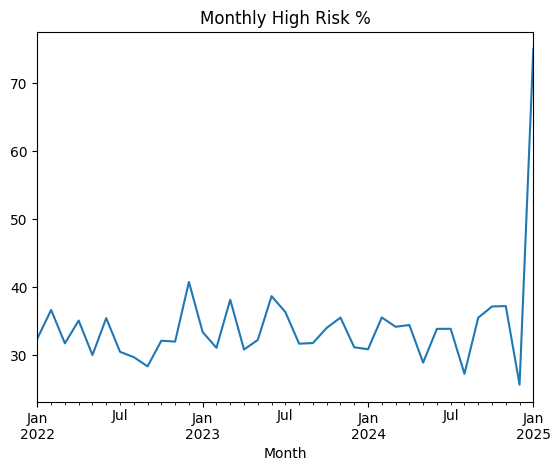

In [ ]:
df["High_Risk"] = (df["RSI"] > 0.5).astype(int)

monthly_risk = df.groupby("Month")["High_Risk"].mean() * 100

monthly_risk.plot(title="Monthly High Risk %")

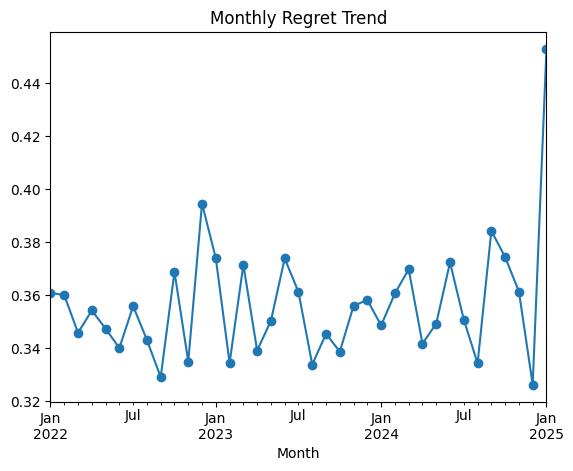

In [ ]:
import matplotlib.pyplot as plt

monthly_trend.plot(marker='o', title="Monthly Regret Trend")
plt.show()

In [ ]:
high_risk_months = monthly_risk[monthly_risk > 40]

print("High Risk Months:")
print(high_risk_months)

High Risk Months:
Month
2022-12    40.703518
2025-01    75.000000
Freq: M, Name: High_Risk, dtype: float64


In [ ]:
early = monthly_trend.iloc[:6].mean()
late = monthly_trend.iloc[-6:].mean()

print("Early RSI:", early)
print("Late RSI:", late)

Early RSI: 0.35133690468010786
Late RSI: 0.37215969804706767


3. Product Trend

<Axes: title={'center': 'Top Products Risk Trend'}, xlabel='Month'>

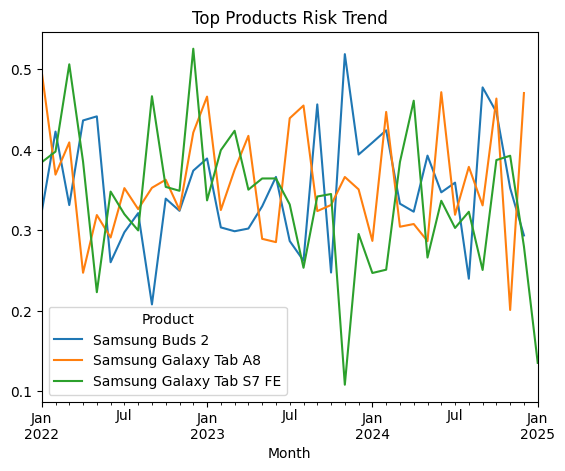

In [ ]:
top_products = df["Product"].value_counts().head(3).index

df_top = df[df["Product"].isin(top_products)]

trend = df_top.groupby(["Month", "Product"])["RSI"].mean().unstack()

trend.plot(title="Top Products Risk Trend")

4. Platform Trend

<Axes: title={'center': 'Platform Risk Trend'}, xlabel='Month'>

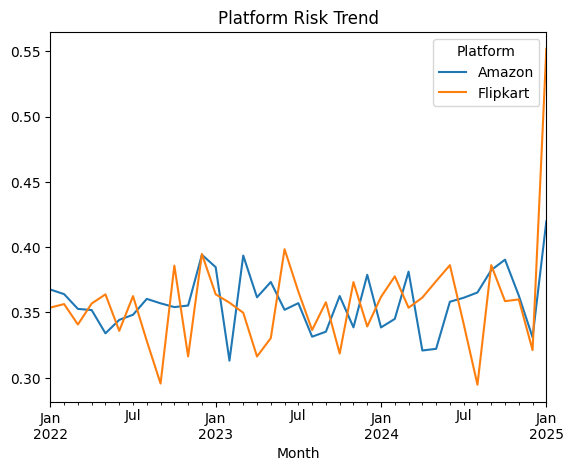

In [ ]:
platform_trend = df.groupby(["Month", "Platform"])["RSI"].mean().unstack()

platform_trend.plot(title="Platform Risk Trend")

In [ ]:
print(monthly_trend.head())

Month
2022-01    0.360792
2022-02    0.359972
2022-03    0.345731
2022-04    0.354174
2022-05    0.347348
Freq: M, Name: RSI, dtype: float64


In [ ]:
print("Early RSI:", early)
print("Late RSI:", late)

Early RSI: 0.35133690468010786
Late RSI: 0.37215969804706767


OLAP OPERATIONS

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/DWDM_Project/data/processed/samsung_processed_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

1. ROLL-UP

In [ ]:
rollup = df.groupby("Category")["RSI"].mean().sort_values(ascending=False)

print("ROLL-UP (Category level RSI):")
print(rollup)

ROLL-UP (Category level RSI):
Category
Other          0.369057
Accessories    0.359437
Smartphone     0.352025
TV             0.350709
Name: RSI, dtype: float64


Interpretation:

• The “Other” category shows the highest average RSI, indicating higher dissatisfaction.

• Smartphones and TVs have relatively lower RSI, suggesting more stable performance.

• Category-level aggregation helps identify which product groups are riskier.

2. DRILL-DOWN

In [ ]:
drilldown = df.groupby(["Year", "Month"])["RSI"].mean()

print("DRILL-DOWN (Year → Month):")
print(drilldown.head(10))

DRILL-DOWN (Year → Month):
Year  Month
2022  1        0.360792
      2        0.359972
      3        0.345731
      4        0.354174
      5        0.347348
      6        0.340005
      7        0.355810
      8        0.343063
      9        0.329039
      10       0.368707
Name: RSI, dtype: float64


Interpretation

• Monthly-level analysis shows how regret varies over time.

• No sharp spikes indicate consistent product quality.

• Minor fluctuations suggest localized dissatisfaction periods.

3. SLICE

In [ ]:
slice_data = df[df["Category"] == "Smartphone"]

slice_result = slice_data.groupby("Product")["RSI"].mean().sort_values(ascending=False)

print("SLICE (Smartphones only):")
print(slice_result.head(10))

SLICE (Smartphones only):
Product
 Samsung Galaxy Buds2      0.390473
Samsung Galaxy Buds2       0.379174
 Samsung Galaxy S22        0.376562
 Samsung Galaxy Watch6     0.373030
 Samsung Galaxy Tab A8     0.367253
Samsung Galaxy Book 2      0.367194
 Samsung Galaxy A14        0.365708
 Samsung Galaxy M14        0.365469
 Samsung Galaxy M34        0.363602
Samsung Galaxy Tab A8      0.361883
Name: RSI, dtype: float64


Interpretation

• Within smartphones, certain models show higher RSI, indicating product-specific issues.

• This helps identify underperforming products within a category.

4. DICE

In [ ]:
dice_data = df[
    (df["Category"] == "Smartphone") &
    (df["Platform"] == "Amazon") &
    (df["Year"] == 2024)
]

dice_result = dice_data.groupby("Product")["RSI"].mean().sort_values(ascending=False)

print("DICE (Smartphone + Amazon + 2024):")
print(dice_result.head(10))

DICE (Smartphone + Amazon + 2024):
Product
Samsung Galaxy Buds2       0.435000
 Samsung Galaxy A14        0.425305
 Samsung Galaxy S21 FE     0.418758
 Samsung Galaxy Book 2     0.417728
 Samsung Galaxy Book 3     0.399363
Samsung Galaxy Tab A8      0.389293
Samsung Galaxy Book 2      0.387886
Samsung Galaxy A34         0.377879
Samsung Galaxy M34         0.372102
Samsung Galaxy S23         0.371628
Name: RSI, dtype: float64


Interpretation

• Multi-dimensional filtering reveals specific product risks under defined conditions.

• This allows targeted analysis, such as platform-specific dissatisfaction trends.

<Axes: title={'center': 'Category Level Risk (Roll-up)'}, xlabel='Category'>

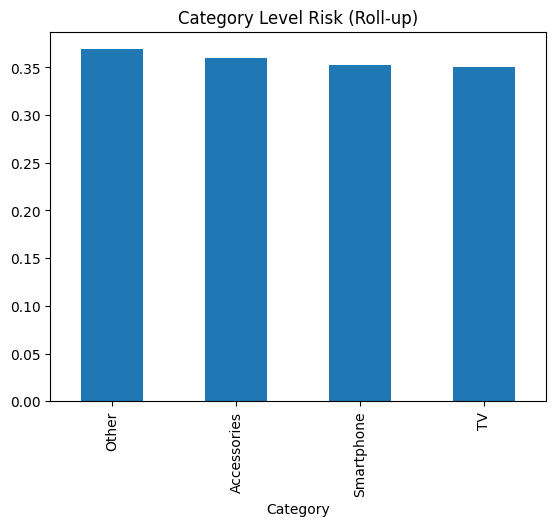

In [ ]:
rollup.plot(kind="bar", title="Category Level Risk (Roll-up)")

“We used OLAP operations to analyze data across multiple dimensions such as category, time, platform, and product to support decision-making.”

 RISK SCORING ENGINE

 Risk Score = Avg RSI × Growth Rate × Issue Density

STEP 1 — Avg RSI per product

In [68]:
df["Product"] = df["Product"].str.strip().str.lower()

In [69]:
product_rsi = df.groupby("Product")["RSI"].mean()

 STEP 2 — Growth Rate (time trend)

In [70]:
monthly_product = df.groupby(["Product", "Month"])["RSI"].mean().reset_index()

growth = monthly_product.groupby("Product")["RSI"].apply(lambda x: x.iloc[-1] - x.iloc[0])

STEP 3 — Issue Density

In [71]:
issue_density = df[df['Issue'] != 'none'].groupby('Product').size() / df.groupby('Product').size()
issue_density = issue_density.fillna(0)

In [76]:
monthly_product = df.groupby(["Product", "Month"])["RSI"].mean().reset_index()

growth = monthly_product.groupby("Product")["RSI"].apply(lambda x: x.iloc[-1] - x.iloc[0])

STEP 4 — Combine everything

In [77]:
risk_df = pd.DataFrame({
    "Avg_RSI": product_rsi,
    "Growth": growth,
    "Issue_Density": issue_density
}).fillna(0)

STEP 5 — Calculate Risk Score

In [86]:
risk_df["Risk_Score"] = (
    0.5 * risk_df["Avg_RSI"] +
    0.3 * risk_df["Growth"] +
    0.2 * risk_df["Issue_Density"]
)

STEP 6 — Normalize

In [108]:
risk_df["Growth"] = (risk_df["Growth"] - risk_df["Growth"].min()) / (
    risk_df["Growth"].max() - risk_df["Growth"].min()
)

STEP 7 — Classify Risk Levels

In [109]:
q1 = risk_df["Risk_Score"].quantile(0.25)
q2 = risk_df["Risk_Score"].quantile(0.5)
q3 = risk_df["Risk_Score"].quantile(0.75)

def classify_risk(score):
    if score <= q1:
        return "Low"
    elif score <= q2:
        return "Moderate"
    elif score <= q3:
        return "High"
    else:
        return "Critical"

risk_df["Risk_Level"] = risk_df["Risk_Score"].apply(classify_risk)

In [110]:
risk_df["Growth"] = risk_df["Growth"].clip(lower=0)

STEP 8 — Sort results

In [111]:
risk_df = risk_df.sort_values(by="Risk_Score", ascending=False)

print(risk_df.head(10))

                          Avg_RSI    Growth  Issue_Density  Risk_Score  \
Product                                                                  
samsung crystal uhd tv   0.356822  1.000000       0.647059    0.607823   
samsung washing machine  0.386860  0.286014       0.750000    0.429234   
samsung air conditioner  0.393665  0.000000       0.758621    0.348557   
samsung galaxy a14       0.361290  0.137623       0.557971    0.333526   
samsung galaxy buds2     0.383411  0.000000       0.656250    0.322956   
samsung galaxy book 2    0.364048  0.105409       0.537572    0.321161   
samsung soundbar         0.368090  0.000000       0.666667    0.317378   
samsung galaxy m53       0.338379  0.134735       0.489224    0.307455   
samsung galaxy watch6    0.352138  0.000000       0.638889    0.303847   
samsung qled tv          0.344596  0.000000       0.647059    0.301710   

                        Risk_Level  
Product                             
samsung crystal uhd tv    Critical  


<Axes: title={'center': 'Top Risky Products'}, xlabel='Product'>

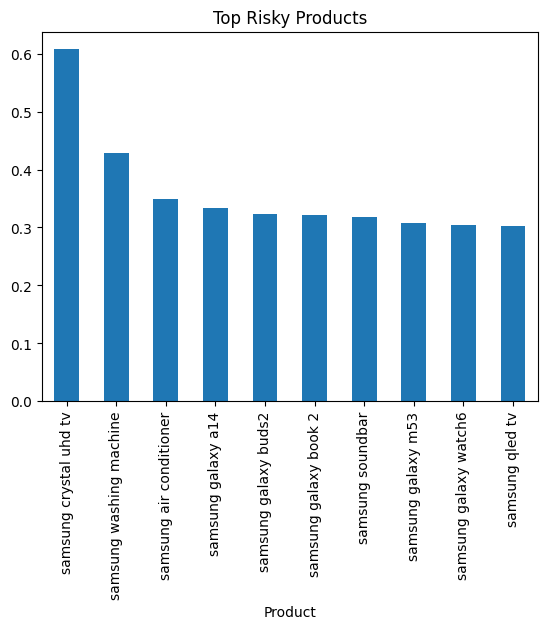

In [112]:
risk_df["Risk_Score"].head(10).plot(kind="bar", title="Top Risky Products")

In [113]:
print(risk_df.head(10))

                          Avg_RSI    Growth  Issue_Density  Risk_Score  \
Product                                                                  
samsung crystal uhd tv   0.356822  1.000000       0.647059    0.607823   
samsung washing machine  0.386860  0.286014       0.750000    0.429234   
samsung air conditioner  0.393665  0.000000       0.758621    0.348557   
samsung galaxy a14       0.361290  0.137623       0.557971    0.333526   
samsung galaxy buds2     0.383411  0.000000       0.656250    0.322956   
samsung galaxy book 2    0.364048  0.105409       0.537572    0.321161   
samsung soundbar         0.368090  0.000000       0.666667    0.317378   
samsung galaxy m53       0.338379  0.134735       0.489224    0.307455   
samsung galaxy watch6    0.352138  0.000000       0.638889    0.303847   
samsung qled tv          0.344596  0.000000       0.647059    0.301710   

                        Risk_Level  
Product                             
samsung crystal uhd tv    Critical  


In [114]:
risk_level_counts = risk_df['Risk_Level'].value_counts()
print(risk_level_counts)

Risk_Level
Low         7
Critical    6
High        6
Moderate    6
Name: count, dtype: int64


<Axes: title={'center': 'Risk Level Distribution'}, xlabel='Risk_Level'>

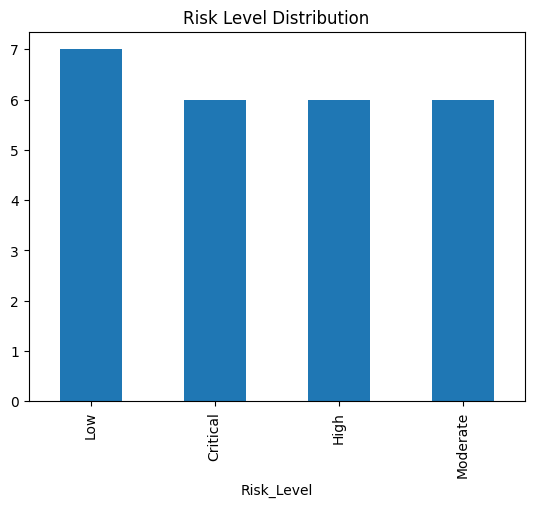

In [117]:
risk_df["Risk_Level"].value_counts().plot(kind="bar", title="Risk Level Distribution")